In [6]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


🎯 ACCURATE BLACK BACKGROUND EXTRACTION
✅ Model loaded
📤 Upload images:


Saving apple_158989157.jpg to apple_158989157 (16).jpg
Saving download (1).jfif to download (1) (10).jfif
Saving download (2).jfif to download (2) (3).jfif
Saving download (3).jfif to download (3) (16).jfif
Saving download.jfif to download (18).jfif
Saving EA019746.webp to EA019746 (1).webp
Saving ii.jfif to ii (1).jfif
Saving images (1).jfif to images (1) (16).jfif
Saving images.jfif to images (18).jfif
Saving lionel-messi_imago1019567000h.jpg to lionel-messi_imago1019567000h.jpg
🔄 Processing: apple_158989157 (16).jpg


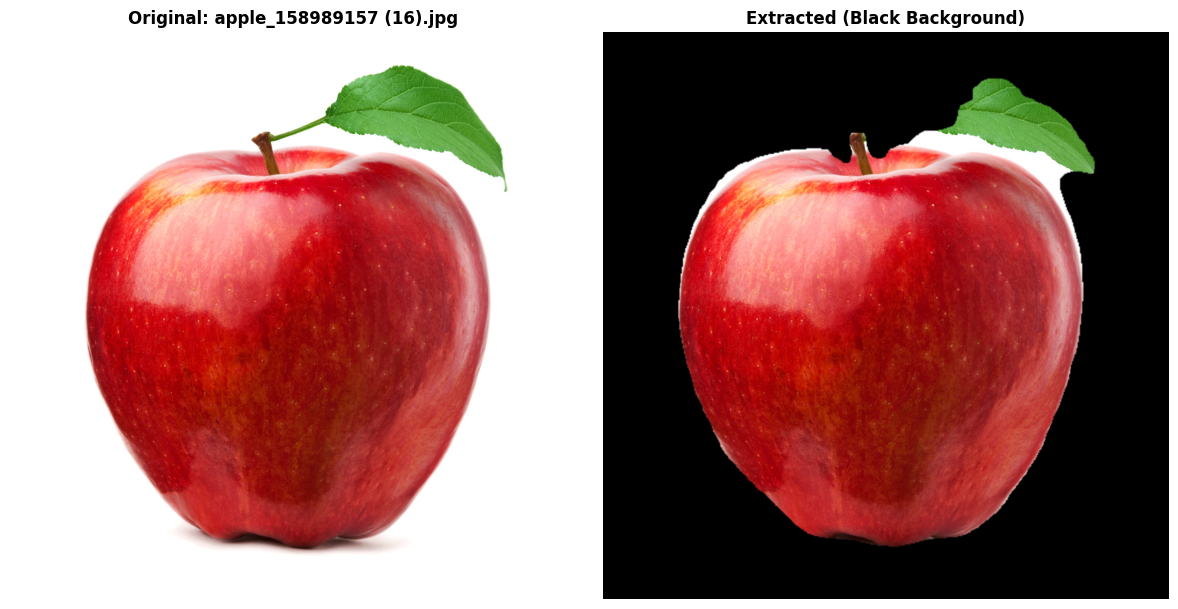

✅ Done: apple_158989157 (16).jpg
🔄 Processing: download (1) (10).jfif


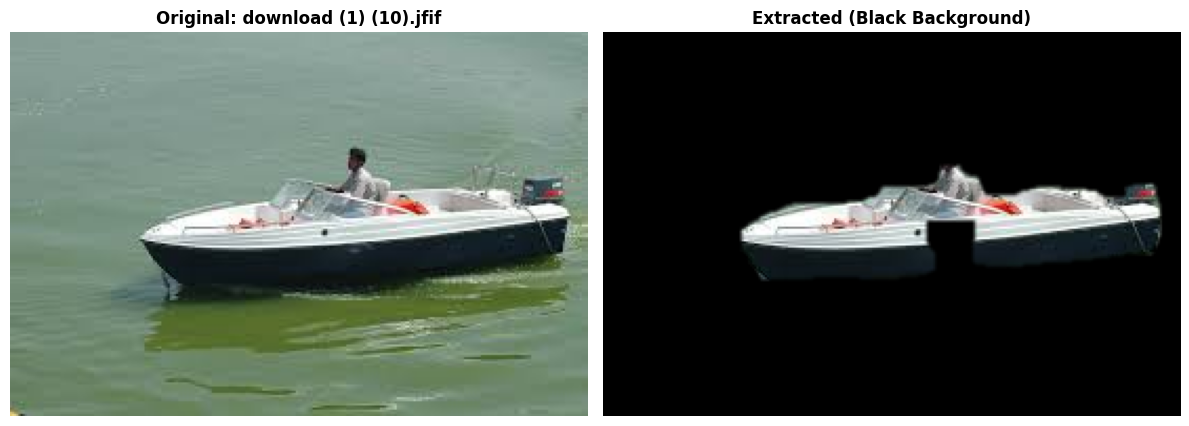

✅ Done: download (1) (10).jfif
🔄 Processing: download (2) (3).jfif


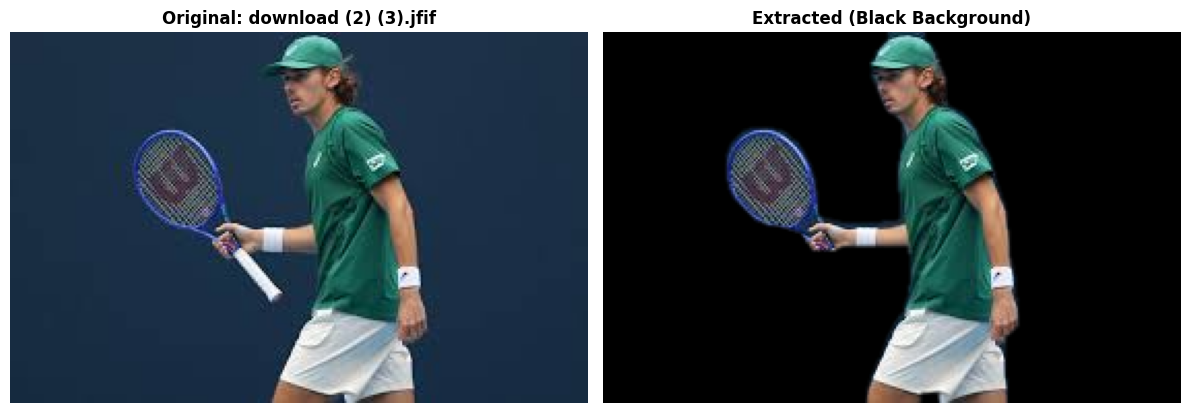

✅ Done: download (2) (3).jfif
🔄 Processing: download (3) (16).jfif


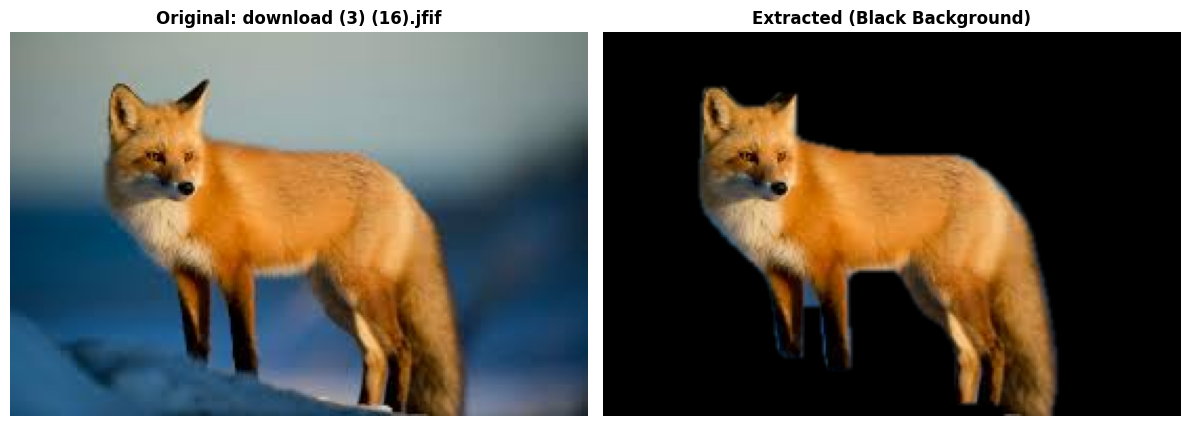

✅ Done: download (3) (16).jfif
🔄 Processing: download (18).jfif


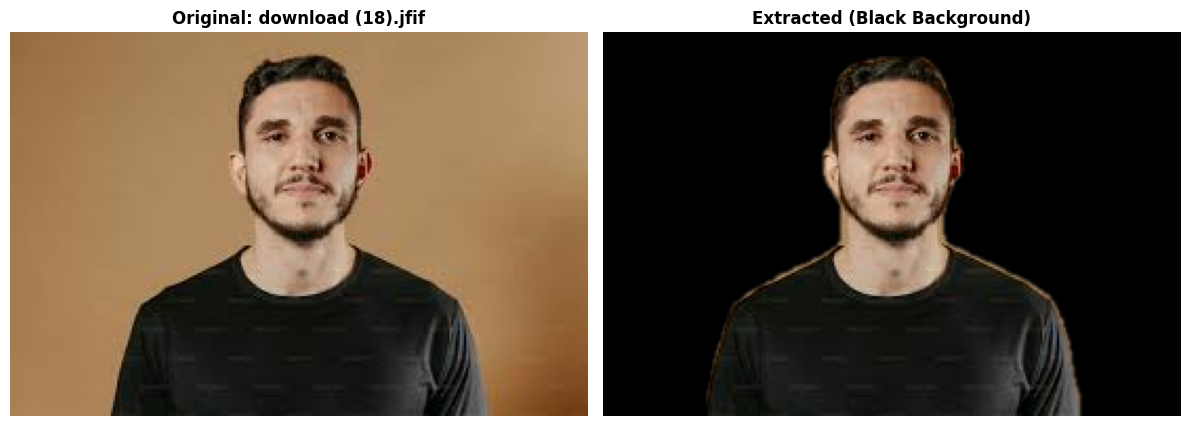

✅ Done: download (18).jfif
🔄 Processing: EA019746 (1).webp


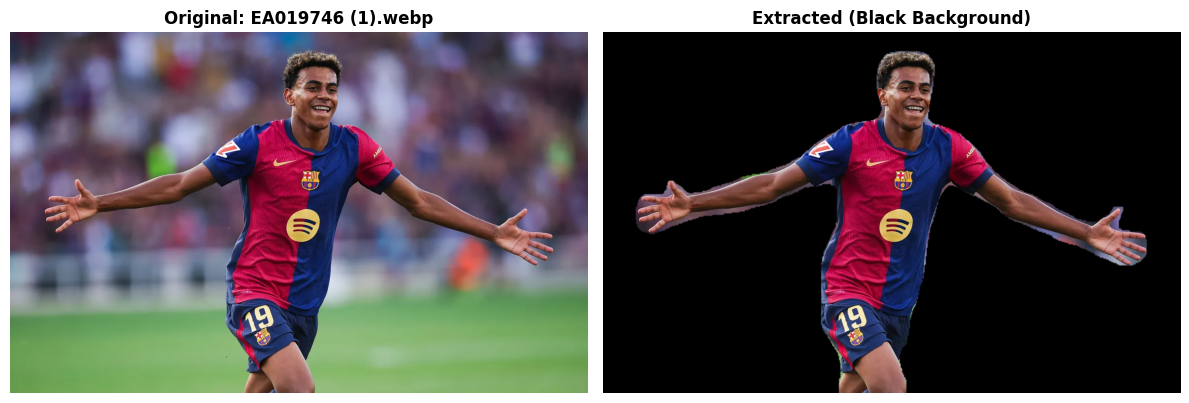

✅ Done: EA019746 (1).webp
🔄 Processing: ii (1).jfif


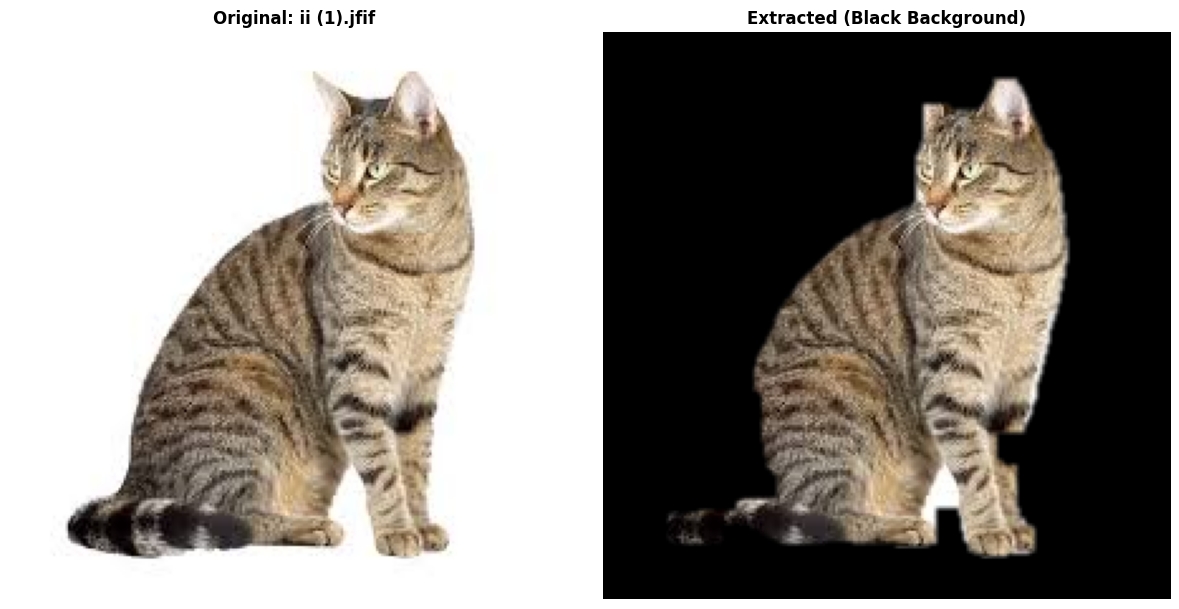

✅ Done: ii (1).jfif
🔄 Processing: images (1) (16).jfif


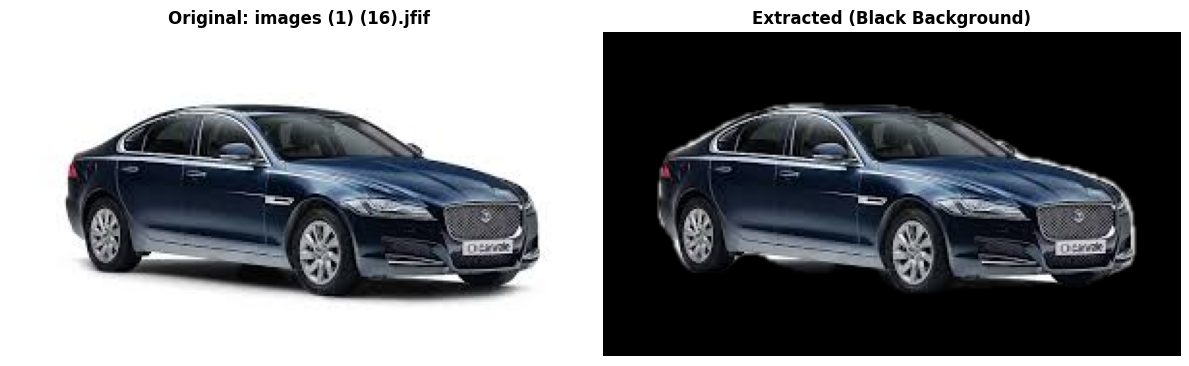

✅ Done: images (1) (16).jfif
🔄 Processing: images (18).jfif


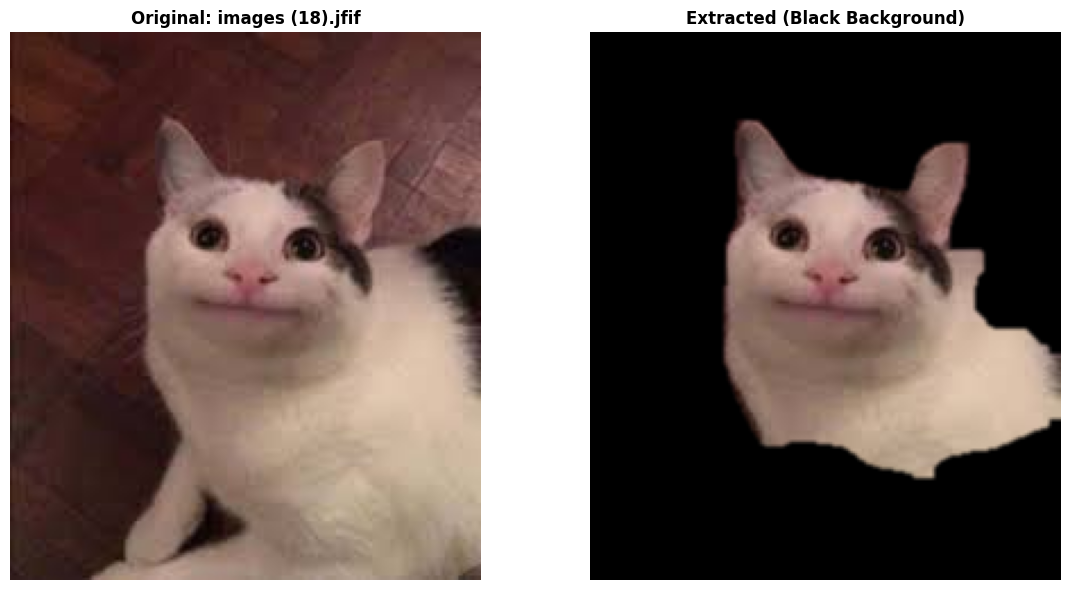

✅ Done: images (18).jfif
🔄 Processing: lionel-messi_imago1019567000h.jpg


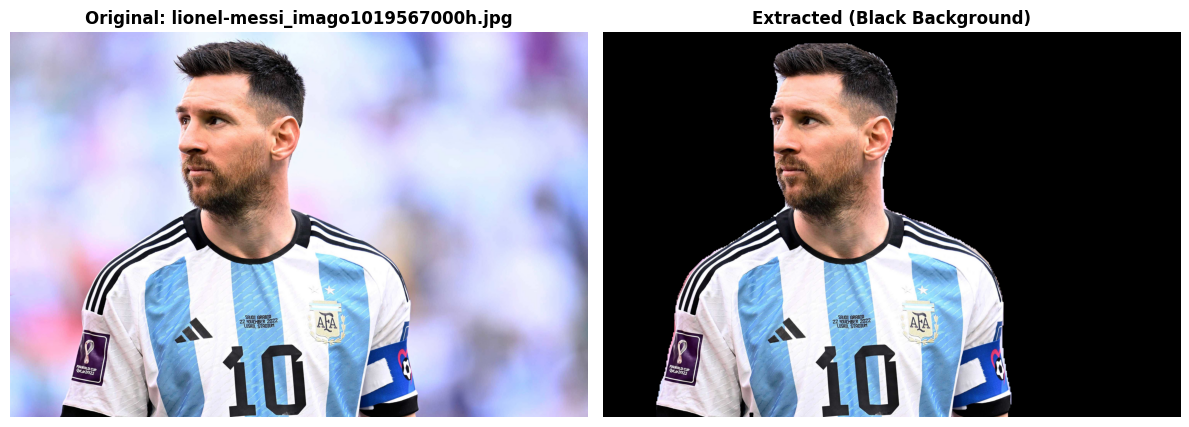

✅ Done: lionel-messi_imago1019567000h.jpg


In [32]:
import torch
import numpy as np
import cv2
from torchvision.models.segmentation import deeplabv3_resnet50
import torch.nn as nn
from google.colab import files
from PIL import Image
import io
import matplotlib.pyplot as plt

print("🎯 ACCURATE BLACK BACKGROUND EXTRACTION")
print("=" * 50)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load your model
model_path = "/content/drive/MyDrive/deeplabv3_segmentation.pth"

model = deeplabv3_resnet50(pretrained=False, aux_loss=True)
model.classifier[4] = nn.Conv2d(256, 2, kernel_size=1)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()
print("✅ Model loaded")

def enhanced_process_image(image_data):
    # Load image
    image = Image.open(io.BytesIO(image_data))
    img_rgb = np.array(image)
    h, w = img_rgb.shape[:2]

    # Use higher resolution for better accuracy
    scale = 512 / max(h, w)  # Increased from 256 to 512
    new_w, new_h = int(w * scale), int(h * scale)
    img_resized = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)

    # Convert to tensor
    img_tensor = torch.tensor(img_resized / 255., dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    img_tensor = (img_tensor - mean) / std
    img_tensor = img_tensor.to(device)

    # Predict with TTA (Test Time Augmentation) for better accuracy
    with torch.no_grad():
        # Original prediction
        output1 = model(img_tensor)['out']

        # Horizontal flip prediction
        flipped = torch.flip(img_tensor, [3])
        output2 = model(flipped)['out']
        output2 = torch.flip(output2, [3])  # Flip back

        # Average predictions
        avg_output = (output1 + output2) / 2.0
        pred_mask = torch.argmax(avg_output, dim=1).squeeze(0).cpu().numpy()

    # Resize mask to original size with better interpolation
    mask = cv2.resize(pred_mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_LINEAR)

    # Enhanced mask cleaning
    kernel = np.ones((5, 5), np.uint8)

    # Remove small noise
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # Fill holes (FIXED: lowercase 'm')
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Keep only largest connected component
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if num_labels > 1:
        largest_label = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
        mask = (labels == largest_label).astype(np.uint8)

    # Smooth edges
    mask = cv2.GaussianBlur(mask.astype(np.float32), (3, 3), 0)
    mask = (mask > 0.5).astype(np.uint8)

    # Create black background with smooth edges
    black_bg = np.zeros_like(img_rgb)

    # Apply smooth transition
    mask_smooth = cv2.GaussianBlur(mask.astype(np.float32), (3, 3), 0)
    for c in range(3):
        black_bg[:, :, c] = img_rgb[:, :, c] * mask_smooth

    return img_rgb, black_bg.astype(np.uint8)

# Main
print("📤 Upload images:")
uploaded = files.upload()

for filename, file_data in uploaded.items():
    print(f"🔄 Processing: {filename}")

    original, black_bg = enhanced_process_image(file_data)

    # Show both images side by side
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title(f"Original: {filename}", fontweight='bold', fontsize=12)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(black_bg)
    plt.title("Extracted (Black Background)", fontweight='bold', fontsize=12)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"✅ Done: {filename}")